#Scalable Big Data Analysis on Amazon Sales Dataset Using PySpark

In [7]:
# =========================================================
# BIG DATA ANALYSIS USING PYSPARK
# AMAZON SALES DATASET
# =========================================================

In [2]:
# Importing operating system library
# Used for Spark local IP configuration
import os

In [3]:
# Setting Spark to run locally
# Prevents Spark hostname errors
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

In [4]:
# Importing SparkSession
# SparkSession is the entry point for PySpark
from pyspark.sql import SparkSession

In [5]:
# Importing all important PySpark functions
from pyspark.sql.functions import *


In [6]:
import matplotlib.pyplot as plt
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [14]:
# =========================================================
# CREATING SPARK SESSION
# =========================================================

In [7]:
# Creating Spark Session
# local[*] means Spark uses all CPU cores available
# appName gives a name to the Spark application

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("AmazonSalesAnalysis") \
    .getOrCreate()
# Display confirmation message
print("Spark Session Created Successfully")

Spark Session Created Successfully


In [8]:
# =========================================================
# LOADING AMAZON SALES DATASET
# =========================================================

# Reading CSV dataset using PySpark

df = spark.read.csv(
    "Amazon Sale Report.csv",   # Dataset file name
    header=True,                # First row contains column names
    inferSchema=True            # Automatically detect data types
)

In [9]:
df

DataFrame[index: int, Order ID: string, Date: string, Status: string, Fulfilment: string, Sales Channel: string, ship-service-level: string, Category: string, Size: string, Courier Status: string, Qty: int, currency: string, Amount: double, ship-city: string, ship-state: string, ship-postal-code: int, ship-country: string, B2B: boolean, fulfilled-by: string, New: string, PendingS: string]

In [10]:
df.show(5)

+-----+-------------------+--------+--------------------+----------+-------------+------------------+--------+----+--------------+---+--------+------+-----------+-----------+----------------+------------+-----+------------+----+--------+
|index|           Order ID|    Date|              Status|Fulfilment|Sales Channel|ship-service-level|Category|Size|Courier Status|Qty|currency|Amount|  ship-city| ship-state|ship-postal-code|ship-country|  B2B|fulfilled-by| New|PendingS|
+-----+-------------------+--------+--------------------+----------+-------------+------------------+--------+----+--------------+---+--------+------+-----------+-----------+----------------+------------+-----+------------+----+--------+
|    0|405-8078784-5731545|04-30-22|           Cancelled|  Merchant|    Amazon.in|          Standard| T-shirt|   S|    On the Way|  0|     INR|647.62|     MUMBAI|MAHARASHTRA|          400081|          IN|false|   Easy Ship|NULL|    NULL|
|    1|171-9198151-1101146|04-30-22|Shipped - De

In [12]:
total_rows = df.count()
print("Total Number of Rows:", total_rows)

Total Number of Rows: 128976


In [14]:
total_columns = len(df.columns)

# Display total columns
print("Total Number of Columns:", total_columns)
print(df.columns)

Total Number of Columns: 21
['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel', 'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS']


In [15]:
df.printSchema()

root
 |-- index: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Fulfilment: string (nullable = true)
 |-- Sales Channel: string (nullable = true)
 |-- ship-service-level: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- Courier Status: string (nullable = true)
 |-- Qty: integer (nullable = true)
 |-- currency: string (nullable = true)
 |-- Amount: double (nullable = true)
 |-- ship-city: string (nullable = true)
 |-- ship-state: string (nullable = true)
 |-- ship-postal-code: integer (nullable = true)
 |-- ship-country: string (nullable = true)
 |-- B2B: boolean (nullable = true)
 |-- fulfilled-by: string (nullable = true)
 |-- New: string (nullable = true)
 |-- PendingS: string (nullable = true)



In [16]:
df.describe().show()

+-------+-----------------+-------------------+--------+---------+----------+-------------+------------------+--------+------+--------------+------------------+--------+-----------------+--------------------+-----------------+-----------------+------------+------------+----+--------+
|summary|            index|           Order ID|    Date|   Status|Fulfilment|Sales Channel|ship-service-level|Category|  Size|Courier Status|               Qty|currency|           Amount|           ship-city|       ship-state| ship-postal-code|ship-country|fulfilled-by| New|PendingS|
+-------+-----------------+-------------------+--------+---------+----------+-------------+------------------+--------+------+--------------+------------------+--------+-----------------+--------------------+-----------------+-----------------+------------+------------+----+--------+
|  count|           128976|             128976|  128976|   128976|    128976|       128976|            128976|  128976|128976|        128976|    

In [20]:
# =========================================================
# CHECKING MISSING VALUES
# =========================================================

# Counting NULL values in every column

missing_values = df.select([
    
    count(when(col(c).isNull(), c)).alias(c)
    
    for c in df.columns
])

# Converting Spark DataFrame result into dictionary format

missing_dict = missing_values.first().asDict()

# Displaying missing values column by column

print("Missing Values in Each Column:\n")

for column, value in missing_dict.items():
    print(f"{column} : {value}")

Missing Values in Each Column:

index : 0
Order ID : 0
Date : 0
Status : 0
Fulfilment : 0
Sales Channel : 0
ship-service-level : 0
Category : 0
Size : 0
Courier Status : 0
Qty : 0
currency : 7800
Amount : 7800
ship-city : 35
ship-state : 35
ship-postal-code : 35
ship-country : 35
B2B : 0
fulfilled-by : 89713
New : 128976
PendingS : 128976


In [21]:
# =========================================================
# REMOVING NULL VALUES
# =========================================================

# Removing rows where Amount column is NULL

df = df.dropna(subset=['Amount'])

# Display confirmation message
print("Rows With NULL Amount Removed Successfully")

Rows With NULL Amount Removed Successfully


In [22]:
# =========================================================
# CHECKING DUPLICATE ROWS
# =========================================================

# Counting total rows before duplicate removal

before_duplicates = df.count()

# Remove duplicate rows temporarily for comparison

after_duplicates = df.dropDuplicates().count()

# Calculate duplicate count

duplicate_count = before_duplicates - after_duplicates

# Display duplicate count

print("Total Duplicate Rows:", duplicate_count)

Total Duplicate Rows: 157


In [23]:
# =========================================================
# REMOVING DUPLICATE ROWS
# =========================================================

# Permanently removing duplicate rows

df = df.dropDuplicates()

# Display confirmation message

print("Duplicate Rows Removed Successfully")

Duplicate Rows Removed Successfully


In [24]:
# =========================================================
# VERIFYING CLEANED DATASET
# =========================================================

# Display total rows after cleaning

cleaned_rows = df.count()

print("Total Rows After Cleaning:", cleaned_rows)

Total Rows After Cleaning: 121019


In [25]:
# =========================================================
# CATEGORY-WISE SALES ANALYSIS
# =========================================================

# Grouping dataset by product category
# Calculating total sales for each category
# Sorting categories by highest sales

category_sales = df.groupBy("Category") \
    .agg(
        sum("Amount").alias("Total_Sales")
    ) \
    .orderBy(desc("Total_Sales"))

# Display category-wise sales

category_sales.show()

+--------+--------------------+
|Category|         Total_Sales|
+--------+--------------------+
| T-shirt|3.9154132169999994E7|
|   Shirt|2.1269768700000007E7|
| Blazzer|       1.120850612E7|
|Trousers|   5341305.299999999|
| Perfume|           789419.66|
|  Wallet|  458408.18000000005|
|   Socks|            150397.5|
|   Shoes|           123933.76|
|   Watch|               915.0|
+--------+--------------------+



In [26]:
# =========================================================
# STATE-WISE SALES ANALYSIS
# =========================================================

# Grouping dataset by customer state
# Calculating total sales for each state
# Sorting states by highest sales

state_sales = df.groupBy("ship-state") \
    .agg(
        sum("Amount").alias("State_Sales")
    ) \
    .orderBy(desc("State_Sales"))

# Display top 10 states by sales

state_sales.show(10)

+--------------+--------------------+
|    ship-state|         State_Sales|
+--------------+--------------------+
|   MAHARASHTRA|1.3318966379999999E7|
|     KARNATAKA|       1.046538703E7|
|     TELANGANA|   6909670.079999999|
| UTTAR PRADESH|   6814126.079999999|
|    TAMIL NADU|  6510503.7299999995|
|         DELHI|          4228503.97|
|        KERALA|          3821997.58|
|   WEST BENGAL|          3503223.44|
|ANDHRA PRADESH|          3214859.86|
|       HARYANA|  2879146.9900000007|
+--------------+--------------------+
only showing top 10 rows


In [27]:
# =========================================================
# MOST ORDERED PRODUCT CATEGORIES
# =========================================================

# Grouping dataset by product category
# Calculating total quantity ordered
# Sorting categories by highest quantity sold

quantity_analysis = df.groupBy("Category") \
    .agg(
        sum("Qty").alias("Total_Quantity")
    ) \
    .orderBy(desc("Total_Quantity"))

# Display quantity analysis

quantity_analysis.show()

+--------+--------------+
|Category|Total_Quantity|
+--------+--------------+
| T-shirt|         45164|
|   Shirt|         44903|
| Blazzer|         13930|
|Trousers|          9885|
| Perfume|          1051|
|  Wallet|           844|
|   Socks|           397|
|   Shoes|           152|
|   Watch|             3|
+--------+--------------+



In [28]:
# =========================================================
# ORDER STATUS DISTRIBUTION ANALYSIS
# =========================================================

# Grouping dataset by order status
# Counting number of orders in each status

status_analysis = df.groupBy("Status") \
    .count() \
    .orderBy(desc("count"))

# Display order status distribution

status_analysis.show()

+--------------------+-----+
|              Status|count|
+--------------------+-----+
|             Shipped|77505|
|Shipped - Deliver...|28707|
|           Cancelled|10751|
|Shipped - Returne...| 1949|
| Shipped - Picked Up|  973|
|             Pending|  656|
|Pending - Waiting...|  281|
|Shipped - Returni...|  145|
|Shipped - Out for...|   35|
|Shipped - Rejecte...|   11|
|Shipped - Lost in...|    5|
|   Shipped - Damaged|    1|
+--------------------+-----+



In [29]:
# =========================================================
# FULFILMENT METHOD ANALYSIS
# =========================================================

# Grouping dataset by fulfilment method
# Calculating total sales for each fulfilment type

fulfilment_analysis = df.groupBy("Fulfilment") \
    .agg(
        sum("Amount").alias("Total_Sales")
    ) \
    .orderBy(desc("Total_Sales"))

# Display fulfilment analysis

fulfilment_analysis.show()

+----------+--------------------+
|Fulfilment|         Total_Sales|
+----------+--------------------+
|    Amazon|         5.4262165E7|
|  Merchant|2.4234621390000008E7|
+----------+--------------------+



In [30]:
# =========================================================
# TOP SELLING CITIES ANALYSIS
# =========================================================

# Grouping dataset by customer city
# Calculating total sales for each city
# Sorting cities by highest sales

city_sales = df.groupBy("ship-city") \
    .agg(
        sum("Amount").alias("City_Sales")
    ) \
    .orderBy(desc("City_Sales"))

# Display top 10 selling cities

city_sales.show(10)

+---------+------------------+
|ship-city|        City_Sales|
+---------+------------------+
|BENGALURU|6836614.6499999985|
|HYDERABAD|        4941790.25|
|   MUMBAI|3696704.0400000005|
|NEW DELHI|        3608277.78|
|  CHENNAI|        3098745.74|
|     PUNE|2337978.1799999997|
|  KOLKATA|1412815.8699999999|
| GURUGRAM|        1220562.74|
|    THANE|        1003878.29|
|  LUCKNOW|         933926.34|
+---------+------------------+
only showing top 10 rows


In [31]:
# =========================================================
# CONVERTING DATE COLUMN
# =========================================================

# Converting Date column from string format to proper date format

df = df.withColumn(
    "Date",
    to_date(col("Date"), "MM-dd-yy")
)

# Display confirmation message

print("Date Column Converted Successfully")

Date Column Converted Successfully


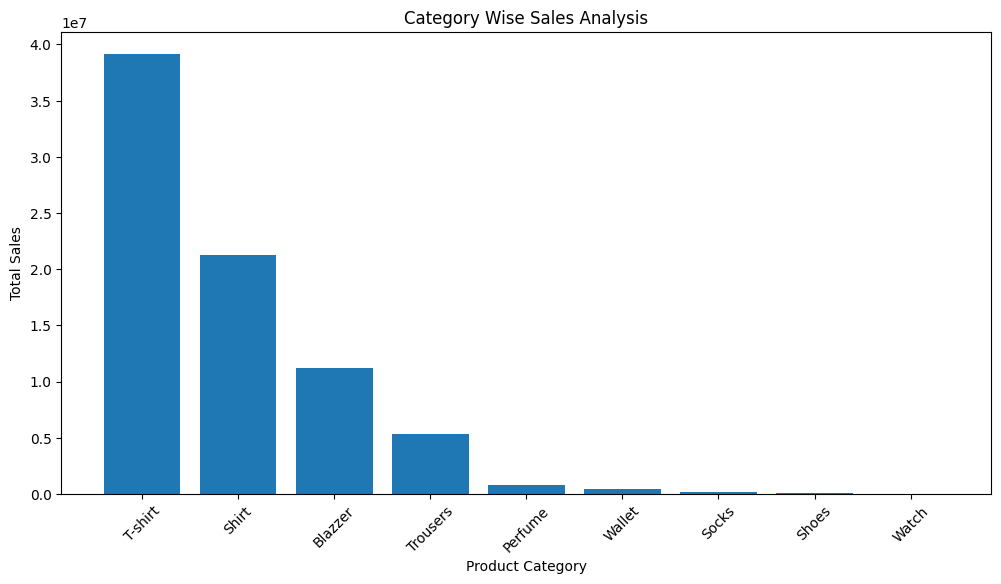

In [35]:
# =========================================================
# CATEGORY-WISE SALES VISUALIZATION
# =========================================================

# Converting Spark DataFrame to Pandas DataFrame
# Matplotlib works better with Pandas

category_pd = category_sales.toPandas()

# Creating bar chart

plt.figure(figsize=(12, 6))

plt.bar(
    category_pd["Category"],
    category_pd["Total_Sales"]
)

# Rotating x-axis labels for better readability

plt.xticks(rotation=45)

# Adding chart title and labels

plt.title("Category Wise Sales Analysis")

plt.xlabel("Product Category")

plt.ylabel("Total Sales")

# Display chart

plt.show()

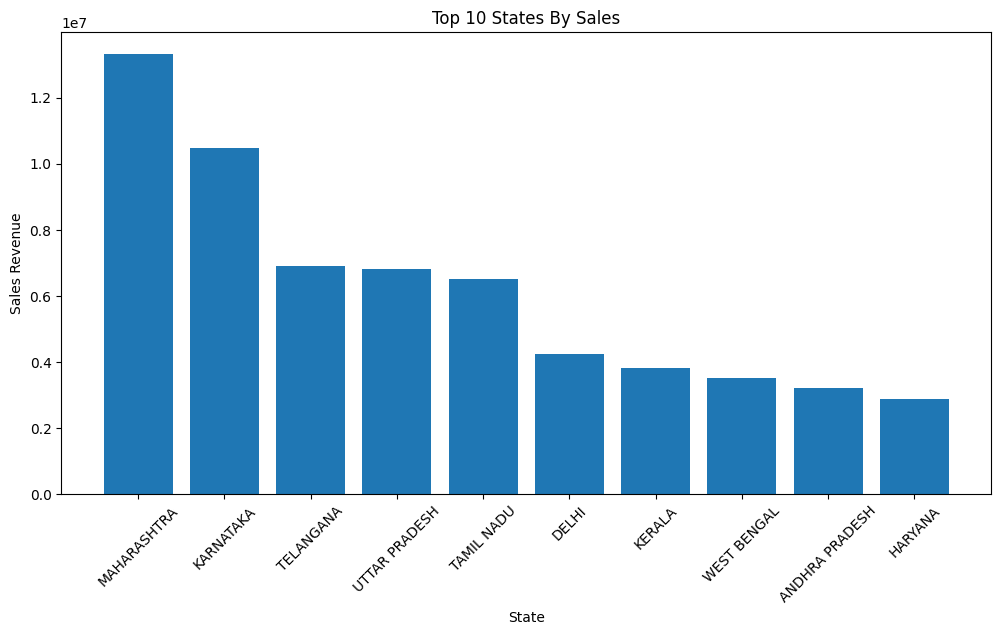

In [36]:
# =========================================================
# STATE-WISE SALES VISUALIZATION
# =========================================================

# Converting top 10 states into Pandas DataFrame

state_pd = state_sales.limit(10).toPandas()

# Creating figure

plt.figure(figsize=(12, 6))

# Creating bar chart

plt.bar(
    state_pd["ship-state"],
    state_pd["State_Sales"]
)

# Rotating labels

plt.xticks(rotation=45)

# Adding chart title and labels

plt.title("Top 10 States By Sales")

plt.xlabel("State")

plt.ylabel("Sales Revenue")

# Display chart

plt.show()

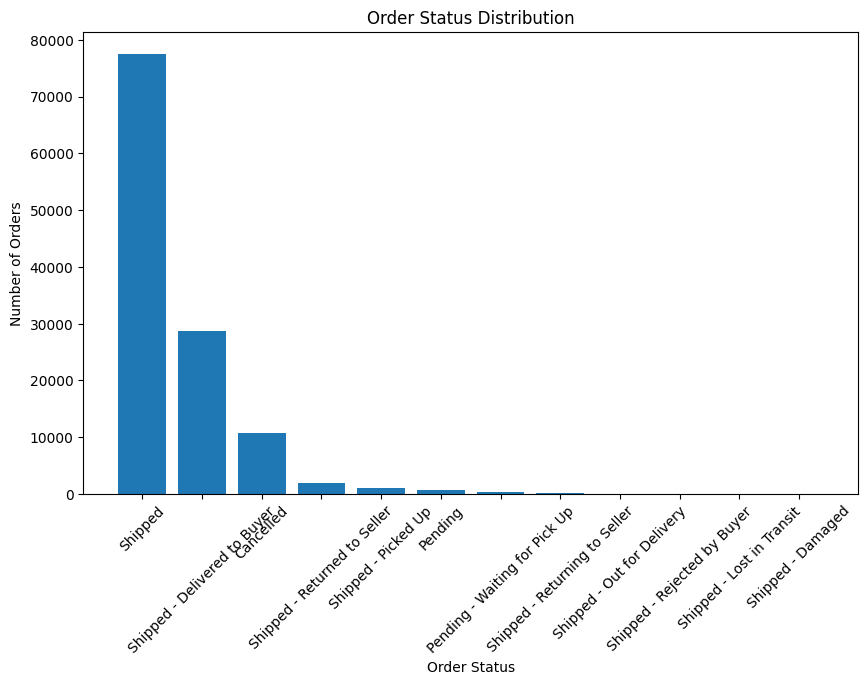

In [37]:
# =========================================================
# ORDER STATUS DISTRIBUTION VISUALIZATION
# =========================================================

# Converting Spark DataFrame to Pandas DataFrame

status_pd = status_analysis.toPandas()

# Creating figure

plt.figure(figsize=(10, 6))

# Creating bar chart

plt.bar(
    status_pd["Status"],
    status_pd["count"]
)

# Rotating labels

plt.xticks(rotation=45)

# Adding chart title and labels

plt.title("Order Status Distribution")

plt.xlabel("Order Status")

plt.ylabel("Number of Orders")

# Display chart

plt.show()

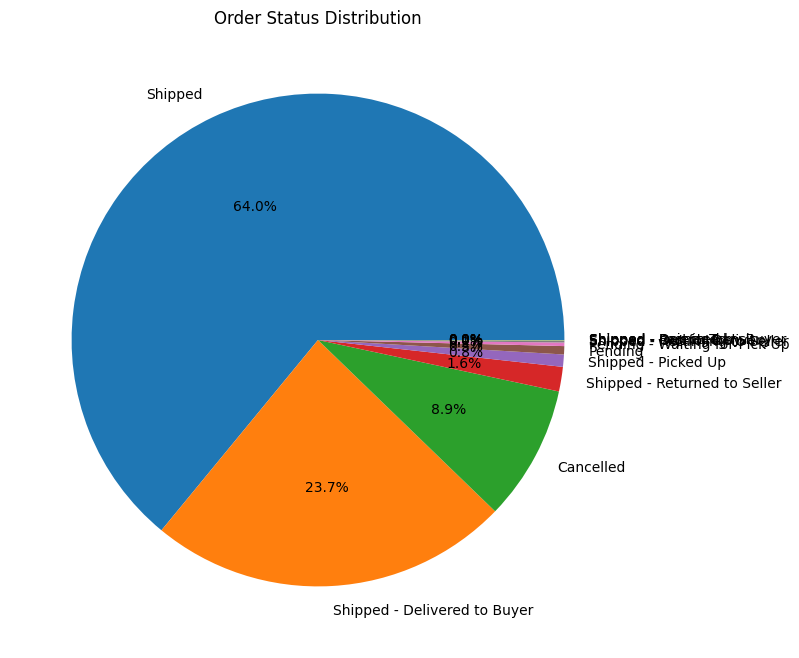

In [44]:
# =========================================================
# PIE CHART - ORDER STATUS DISTRIBUTION
# =========================================================

# Convert Spark DataFrame to Pandas

status_pd = status_analysis.toPandas()

# Create figure

plt.figure(figsize=(8, 8))

# Create pie chart

plt.pie(
    status_pd["count"],
    labels=status_pd["Status"],
    autopct='%1.1f%%'
)

# Add title

plt.title("Order Status Distribution")

# Display chart

plt.show()

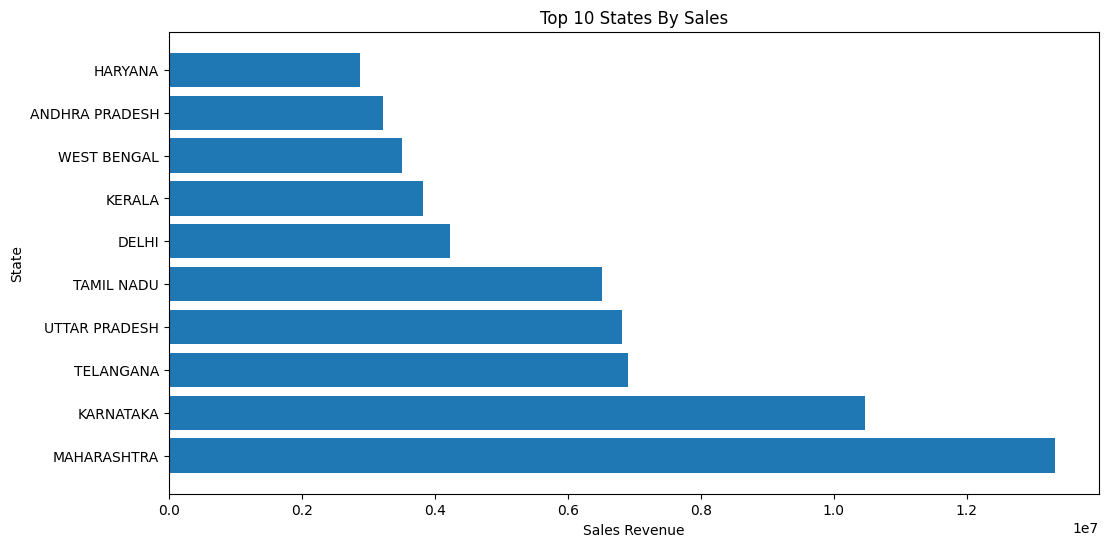

In [46]:
# =========================================================
# HORIZONTAL BAR CHART - TOP STATES
# =========================================================

# Convert Spark DataFrame to Pandas

state_pd = state_sales.limit(10).toPandas()

# Create figure

plt.figure(figsize=(12, 6))

# Create horizontal bar chart

plt.barh(
    state_pd["ship-state"],
    state_pd["State_Sales"]
)

# Add labels and title

plt.title("Top 10 States By Sales")

plt.xlabel("Sales Revenue")

plt.ylabel("State")

# Display graph

plt.show()

# Business Insights

1. Certain product categories generated significantly higher sales revenue compared to others.

2. Some states contributed more sales revenue, indicating stronger regional demand.

3. Metropolitan cities showed higher customer purchasing activity.

4. Most customer orders were successfully processed and shipped.

5. Sales trends varied across different dates, showing fluctuations in customer demand.

6. Fulfilment methods showed different revenue contributions and operational performance.

7. Quantity analysis revealed highly demanded product categories among customers.

# Key Findings

- PySpark successfully handled large-scale sales data efficiently.

- Distributed processing enabled scalable analytics on the dataset.

- Sales aggregation and trend analysis provided meaningful business insights.

- Visualization techniques improved understanding of revenue trends and customer behavior.

- Data cleaning improved dataset quality and analysis reliability.

# Conclusion

This project successfully demonstrated scalable big data analysis using PySpark on the Amazon Sales dataset.

Large-scale sales data was processed efficiently using distributed computing techniques. Various analytical operations such as data cleaning, aggregation, grouping, filtering, trend analysis, and visualization were performed to derive meaningful business insights.

PySpark proved effective for handling large datasets and performing scalable computations efficiently. The project also demonstrated how big data technologies can support business decision-making through data-driven insights.

# Learning Outcomes

Through this project, the following concepts and skills were learned:

- Big Data fundamentals
- PySpark basics
- Distributed data processing
- Data cleaning techniques
- Data aggregation and grouping
- Trend analysis
- Data visualization
- Business insight generation
- Scalable analytics using Spark